In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Module 3.1: The "Why" of Plotting (A Plot is an Argument)

Most people think of a plot as a "picture of data". This is incorrect.

A plot is a **visual argument**. It is a form of communication, a claim you are making about the data. Your goal is not to "make a bar chart"; your goal is to "show a clear comparison between the revenues of three different groups." The bar chart is merely the tool you use to make that argument.

The "Statistician-Pythonista" understands this. The statistician asks, "What is the most honest and powerful argument I can make?" The pythonista asks, "What is the cleanest code to build the tool that makes that argument?"

### Module 3.2: The Grammar of Graphics

Just as English has a grammar (nouns, verbs, adjectives), so do plots. This theory, most famously articulated by Leland Wilkinson and Hadley Wickham, states that any plot is composed of distinct layers.

1.  **The Data:** The raw material. This is your DataFrame.
2.  **The Aesthetics (Mappings):** This is the link between your data and a visual property. You are *mapping* variables.
    * `x-axis_position` $\leftarrow$ `total_bill`
    * `y-axis_position` $\leftarrow$ `tip`
    * `color` $\leftarrow$ `smoker`
    * `size` $\leftarrow$ `party_size`
3.  **The Geometries (Geoms):** This is the *shape* you use to represent the data.
    * `geom_point()` (a scatter plot)
    * `geom_bar()` (a bar chart)
    * `geom_line()` (a line chart)

When you write `seaborn.scatterplot(x='total_bill', y='tip', hue='smoker')`, you are *not* just "making a scatter plot". You are explicitly declaring:
* **Data:** The (implicit) DataFrame.
* **Aesthetics:** Map `total_bill` to the x-axis, `tip` to the y-axis, and `smoker` to color.
* **Geometry:** Use points.

Why does this matter? Because you can change the geometry without changing the aesthetics. You could (though it might not make sense) apply a `geom_line()` to the same aesthetics, and the logic would hold. This "grammar" separates the *data* from its *visual representation*.

### Module 3.3: Graphical Integrity (How Not to Lie)

This is the ethical core of our module. Edward Tufte, a pioneer in this field, wrote extensively about "graphical integrity." The core principle is: **The representation of numbers on the graphic should be directly proportional to the numerical quantities represented.**

Anything else is a form of lying.

**The "Lie Factor"**
Tufte defined the "Lie Factor" as:
$\text{Lie Factor} = \frac{\text{Size of effect shown in graphic}}{\text{Size of effect in data}}$

If your data grew 10% (effect in data = 0.10), but you manipulated the chart so the bar *looks* 50% bigger (effect in graphic = 0.50), your Lie Factor is 5. A Lie Factor of 1 is honest.

The most common ways to lie (which you must avoid):

1.  **The Truncated Y-Axis (The Worst Offense):**
    This is the most common sin in business and media graphics.
    * **The Data:** Group A = 100, Group B = 110. This is a 10% difference.
    * **The Lie:** You start the Y-axis at 95 instead of 0. Now, the bar for Group B (height 15) is *three times taller* than the bar for Group A (height 5).
    * **The Result:** You have visually presented a 200% difference to show a 10% change. This is a lie.
    * **The Rule:** For bar charts, the Y-axis *must* start at 0. Line charts (showing change over time) are an exception, as their primary purpose is to show *slope*.
    

2.  **Using 3D Effects:**
    Never use 3D pie charts, 3D bars, or anything with perspective. The perspective distorts the relative sizes. The "closer" slice of a 3D pie chart looks far larger than an equal-sized slice in the "back". It adds no information and actively misleads.

3.  **Using Area/Volume for 1D Data:**
    If your revenue doubles, you might be tempted to make the *width* and *height* of your icon (e.g., a money bag) twice as big. The result is that the *area* is four times larger. The human eye perceives area, not just height. You have quadratically exaggerated your claim.

### Module 3.4: Choosing the Right Tool (The Statistician's Heuristics)

The final piece of the theory is matching the *question* to the *chart*. When you start an analysis, you have a question. The question dictates the plot.

Here are the four primary questions and their corresponding geometries:

* **1. "What does this variable look like?" (Showing a Distribution)**
    * **Goal:** To understand the *shape* of a single variable: its center, its spread, its skew, and its outliers.
    * **Tools (Geometries):**
        * **`histplot` (Histogram):** The workhorse. Shows frequency counts in discrete bins. Best for understanding the basic shape.
        * **`kdeplot` (Kernel Density Estimate):** A smoothed version of the histogram. Good for seeing the "shape" without the "noise" of bin sizes, but can be misleading (it might imply data exists where it does not, e.g., negative prices).
        * **`boxplot` (Box Plot):** The statistician's summary. Shows the median (50th percentile), the interquartile range (IQR, 25th-75th), and defines outliers (typically as points > 1.5 * IQR from the box). Excellent for comparing distributions across many groups.
        * **`violinplot`:** Combines a `boxplot` (in the middle) with a `kdeplot` (on the sides), showing both the summary statistics *and* the shape of the density.
    

* **2. "How do these two (or more) variables relate?" (Showing a Relationship)**
    * **Goal:** To see how one variable changes as another changes. This is the realm of correlation.
    * **Tools (Geometries):**
        * **`scatterplot`:** The primary tool. Every dot is an observation. You look for patterns: linear, curved, clustered, or no pattern at all.
        * **`pairplot`:** A matrix of scatterplots. The single fastest way to get a "first look" at all pairwise relationships in your dataset.

* **3. "How do these groups compare?" (Showing a Comparison)**
    * **Goal:** To compare a *numeric* value across different *categorical* groups.
    * **Tools (Geometries):**
        * **`barplot`:** The standard. The height of the bar represents a value (e.g., a count, or a `mean` aggregation). Remember: must start at Y=0.
        * **`pointplot`:** A `pointplot` is often better than a `barplot`. It shows the same mean value (the dot) but also adds *confidence intervals* (the vertical lines). This immediately tells you if the difference between two groups is *statistically significant* (if the confidence intervals do not overlap, the difference is likely real).
        * **`boxplot` / `violinplot`:** These are also comparison tools. `boxplot(x='day', y='tip')` is a far more robust comparison than `barplot(x='day', y='tip')`, as the bar plot only shows the *mean*, while the box plot shows the *entire distribution*.

* **4. "What is this data made of?" (Showing Composition)**
    * **Goal:** To show how a whole entity breaks down into parts.
    * **Tools (Geometries):**
        * **Stacked Bar Chart:** Good for showing how a total (the full bar) is divided into parts (the colored segments) across different groups.
        * **Pie Chart / Donut Chart:** Use *sparingly*. The human eye is terrible at comparing angles. It is only acceptable if you have 2-3 categories and want to show a simple "part-of-a-whole" (e.g., 75% Yes, 25% No). A bar chart is almost always better and more honest.



### Part 1: The "Whiteboarding" Exercise (Design)

For each scenario below, I am providing a small, synthetic dataset. Your task is to:

1.  **Experiment:** Run the starter code. Feel free to try multiple plot types (`barplot`, `boxplot`, `scatterplot`, etc.) to see what works and what does not.
2.  **Justify:** Write a short paragraph (2-4 sentences) justifying your *final* choice. Use the principles from Moment 1 (e.g., "A bar chart is poor here because... A boxplot is superior because it shows...").
3.  **Implement:** Provide the clean `seaborn` (or `matplotlib`) code for your chosen plot.

#### Scenario 1: The Unreadable Bar Chart

  * **Goal:** You are a data analyst at a large e-commerce company. A manager wants to see the "average shipping time" for the top 20 product categories.

  * **Minimal Starter Dataset:** This data represents the average shipping time in days for 20 categories.

In [ ]:
def plot_seaborn(
	df: pd.DataFrame,
	x: str = None,
	y: str = None,
	plot_type: str = "scatterplot",
	hue: str = None,
	title: str = "",
	xlabel: str = "",
	ylabel: str = "",
	palette: str = None,
	figsize: tuple = (10, 8),
	grid: bool = True,
	despine: bool = True,
	rotation: int = 0,
	**kwargs,
):
	"""
	Flexible seaborn plotting function with professional defaults.

	Parameters
	----------
	df : pd.DataFrame
		DataFrame containing the data
	x : str, default=None
		Column name for x-axis
	y : str, default=None
		Column name for y-axis
	plot_type : str, default='scatterplot'
		Type of seaborn plot ('scatterplot', 'lineplot', 'barplot', 'histplot', etc.)
	hue : str, default=None
		Column name for color grouping
	title : str, default=''
		Plot title
	xlabel : str, default=''
		X-axis label
	ylabel : str, default=''
		Y-axis label
	palette : str, default=None
		Color palette name
	figsize : tuple, default=(10, 8)
		Figure size tuple (width, height)
	grid : bool, default=True
		Whether to show grid
	despine : bool, default=True
		Whether to remove top/right spines
	rotation : int, default=0
		Rotation angle for x-axis labels (degrees)
	**kwargs : dict
		Additional arguments passed to seaborn plot function

	Returns
	-------
	None
		Displays the plot directly

	Examples
	--------
	>>> plot_seaborn(df, x='total_bill', y='tip', plot_type='scatterplot', hue='smoker')
	>>> plot_seaborn(df, x='day', y='total_bill', plot_type='boxplot', hue='time')
	>>> plot_seaborn(df, x='age', plot_type='histplot', bins=20, kde=True)
	>>> plot_seaborn(df, plot_type='histplot')  # Only data provided

	Notes
	-----
	- Uses matplotlib.pyplot and seaborn which should be imported in previous cells
	- The function automatically handles common plot customization tasks
	- For bar plots, ensure y-axis starts at 0 for graphical integrity
	- For categorical variables with many levels, consider using rotation parameter
	"""
	fig, ax = plt.subplots(figsize=figsize)

	# Map plot type to seaborn function
	plot_func = getattr(sns, plot_type)

	# Create the plot - only include x and y if they are not None
	plot_params = {"data": df, "ax": ax, "palette": palette}
	if x is not None:
		plot_params["x"] = x
	if y is not None:
		plot_params["y"] = y
	if hue:
		plot_params["hue"] = hue

	# Add any additional kwargs
	plot_params.update(kwargs)

	plot_func(**plot_params)

	# Set labels and title
	ax.set(title=title, xlabel=xlabel, ylabel=ylabel)

	# Customize grid
	if grid:
		ax.grid(True, alpha=0.6, linewidth=0.4, color="grey")
		ax.set_axisbelow(True)

	# Remove spines for cleaner look
	if despine:
		sns.despine(ax=ax, top=True, right=True)

	# Rotate x-axis labels if needed
	if rotation:
		plt.xticks(rotation=rotation)

	plt.tight_layout()
	plt.show()

In [ ]:
# Synthetic Data
np.random.seed(42)
categories = [
	"art",
	"automotive",
	"baby",
	"beauty",
	"books",
	"clothing",
	"computers",
	"electronics",
	"garden",
	"grocery",
	"health",
	"home",
	"industrial",
	"jewelry",
	"music",
	"outdoors",
	"pets",
	"sports",
	"tools",
	"toys",
]

data_scenario_1 = pd.DataFrame({
	"category": categories,
	"avg_shipping_days": np.random.uniform(2.5, 9.0, size=len(categories)),
})

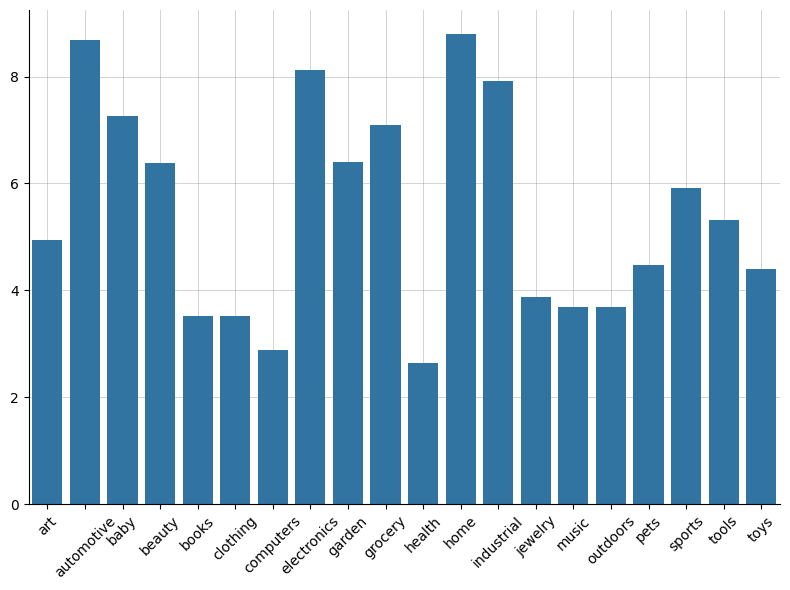

In [ ]:
plot_seaborn(
	df=data_scenario_1,
	x="category",
	y="avg_shipping_days",
	plot_type="barplot",
	rotation=45,
	figsize=(8, 6),
)

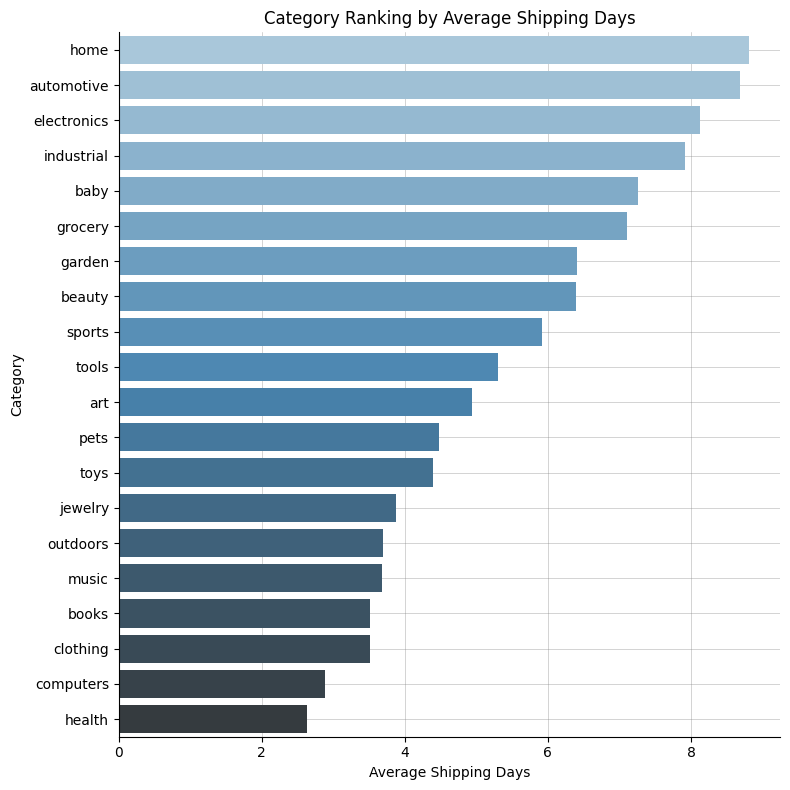

In [ ]:
# Sort the data in descending order
sorted_values = data_scenario_1.sort_values(
	by="avg_shipping_days", ascending=False
).reset_index(drop=True)
sorted_values["rank"] = sorted_values.index + 1  # Add rank column for labeling

plot_seaborn(
	df=sorted_values,
	x="avg_shipping_days",
	y="category",
	plot_type="barplot",
	hue="category",
	palette="Blues_d",
	figsize=(8, 8),
	despine=True,
	xlabel="Average Shipping Days",
	ylabel="Category",
	title="Category Ranking by Average Shipping Days",
)

  * **The Task:** The standard bar chart is a mess (too many categories, unreadable x-axis labels, no clear pattern). Design and implement a *better* visualization that clearly shows the ranking and distribution of shipping times.

#### Scenario 2: The "Blob" of Data (Skewed Variables)

  * **Goal:** You are analyzing a housing dataset. You want to understand the relationship between "median income" (in tens of thousands) and "median house value".

  * **Minimal Starter Dataset:** This data is right-skewed, just like real financial data. Most people have low-to-medium income, but a few have very high income.

In [ ]:
# Synthetic Data (log-normally distributed)
np.random.seed(42)
N_SAMPLES = 500
income = np.random.lognormal(mean=3.0, sigma=0.8, size=N_SAMPLES)

# House value is a function of income + some noise
house_value = (income * 50_000) + np.random.normal(0, 25_000, size=N_SAMPLES)

# Clamp values to be realistic
income = np.clip(income, 1, 50)
house_value = np.clip(house_value, 20_000, 500_000)

data_scenario_2 = pd.DataFrame({
	"median_income_10k": income,
	"median_house_value": house_value,
})

In [ ]:
from sklearn.linear_model import LinearRegression

# Extract variables
X = california[["median_income_10k"]]  # must be 2D
y = california["median_house_value"]

# Fit model
model = LinearRegression()
model.fit(X, y)

beta0 = model.intercept_
beta1 = model.coef_[0]

print(f"β₀ (intercept): {beta0:.3f}")
print(f"β₁ (slope):     {beta1:.3f}")

β₀ (intercept): 0.451
β₁ (slope):     0.418


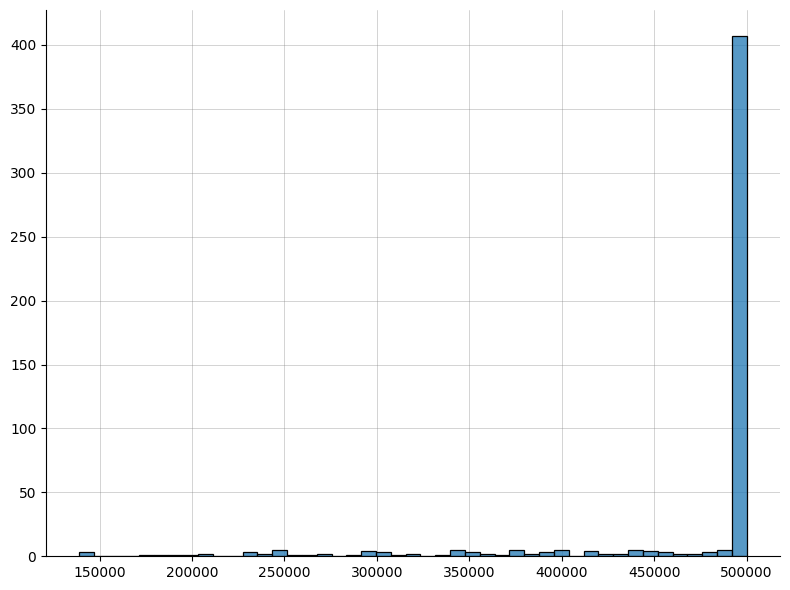

In [ ]:
plot_seaborn(
	df=data_scenario_2,
	x="median_house_value",
	plot_type="histplot",
	figsize=(8, 6),
	despine=True,
)

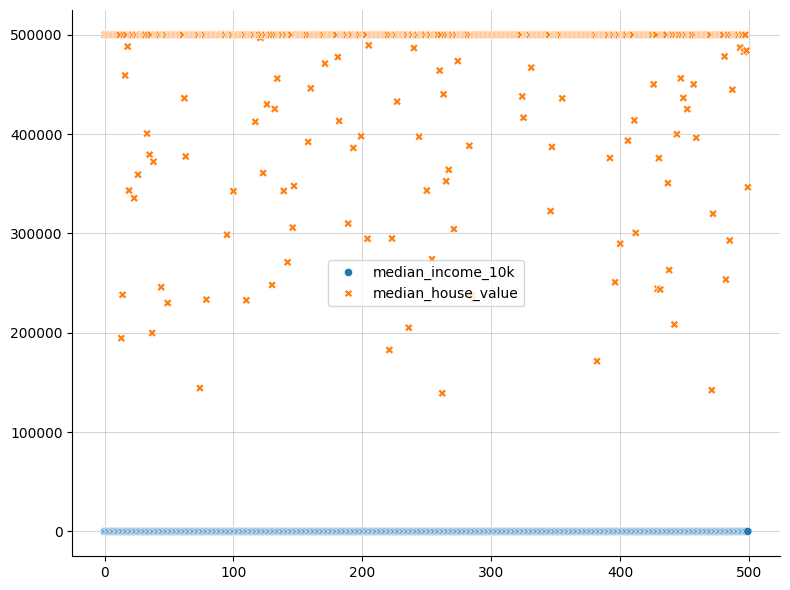

In [ ]:
plot_seaborn(
	df=data_scenario_2,
	plot_type="scatterplot",
	figsize=(8, 6),
	despine=True,
)

In [ ]:
from scipy.stats import norm

sigma = np.std(data_scenario_2["median_house_value"], ddof=1)
mu = np.mean(data_scenario_2["median_house_value"])
x = data_scenario_2["median_house_value"]

pdf_values = norm.pdf(x, mu, sigma)

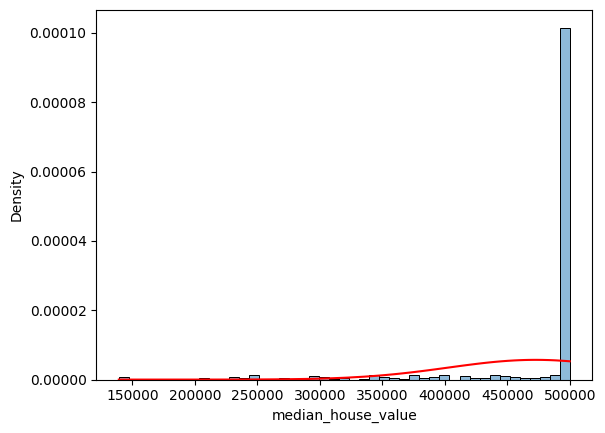

In [ ]:
sns.histplot(x, stat="density", alpha=0.5)
sns.lineplot(x=x, y=pdf_values, color="red")

plt.show()

  * **The Task:** The standard scatter plot is "blobbed" into the bottom-left corner, hiding the true relationship. Design and implement a visualization that *reveals* the underlying pattern. (Hint: How do statisticians handle skewed distributions?).

##### The Tobit Model – Definition and Assumptions

##### Latent Mean (Predicted True Value)
$$
\mu_i = \beta_0 + \beta_1 x_i
$$
- $\mu_i$: Latent mean for observation $i$
- $\beta_0$: Intercept parameter
- $\beta_1$: Slope parameter
- $x_i$: Predictor value (e.g., income) for observation $i$

Vectorized form:
$$
\boldsymbol{\mu} = \mathbf{X} \boldsymbol{\beta}
$$
- $\boldsymbol{\mu}$: Vector of latent means for all observations
- $\mathbf{X}$: Design matrix (n × 2, with column of 1s and predictors)
- $\boldsymbol{\beta}$: Parameter vector $[\beta_0, \beta_1]$

##### Normal Log-PDF (for Uncensored Points)
$$
\log \left( \frac{1}{\sigma} \phi\left( \frac{y_i - \mu_i}{\sigma} \right) \right) = -\log(\sigma) + \log \phi(z_i)
$$
Where:
$$
\phi(z) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{z^2}{2} \right), \quad z_i = \frac{y_i - \mu_i}{\sigma}
$$
Expanded:
$$
- \log(\sigma) - 0.5 \log(2\pi) - 0.5 \left( \frac{y_i - \mu_i}{\sigma} \right)^2
$$
- $\sigma$: Standard deviation of errors
- $\phi(z)$: Standard normal PDF at $z$
- $y_i$: Observed value for observation $i$
- $z_i$: Standardized residual

##### Log-Survival Function (for Censored Points)
$$
\log \left( 1 - \Phi\left( \frac{c - \mu_i}{\sigma} \right) \right) = \log \left( SF(z_i) \right)
$$
Where:
$$
z_i = \frac{c - \mu_i}{\sigma}, \quad \Phi(z) = 0.5 + 0.5 \cdot \operatorname{erf}\left( \frac{z}{\sqrt{2}} \right), \quad SF(z) = 0.5 \cdot \operatorname{erfc}\left( \frac{z}{\sqrt{2}} \right)
$$
- $c$: Censoring threshold (e.g., upper cap)
- $\Phi(z)$: Standard normal CDF at $z$
- $SF(z)$: Standard normal survival function (1 - CDF) at $z$
- $\operatorname{erf}$: Error function
- $\operatorname{erfc}$: Complementary error function (1 - erf)

##### Full Log-Likelihood

$$
\ell(\theta) = \sum_{i \in \text{uncens}} \left[ -\log(\sigma) + \log \phi\left( \frac{y_i - \mu_i}{\sigma} \right) \right] + \sum_{i \in \text{cens}} \log \left( 1 - \Phi\left( \frac{c - \mu_i}{\sigma} \right) \right)
$$
Negative log-likelihood (for minimization):
$$
-\ell(\theta)
$$
- $\theta$: Parameter set $(\beta_0, \beta_1, \sigma)$
- $\text{uncens}$: Set of uncensored observations
- $\text{cens}$: Set of censored observations

In [ ]:
from scipy.stats import norm


def tobit_neg_log_lik(
	params: np.ndarray,
	X: np.ndarray,
	y: np.ndarray,
	upper: float,
) -> float:
	"""
	Compute the negative log-likelihood for the Tobit model with right-censoring.

	The Tobit model is used for censored regression where the dependent variable
	is censored at an upper limit. This function calculates the negative log-likelihood
	for maximum likelihood estimation.

	Parameters
	----------
	params : np.ndarray
		Model parameters. The last element is sigma (standard deviation of the error term),
		and the preceding elements are the beta coefficients (including intercept).
	X : np.ndarray, shape (n_samples, n_features)
		Design matrix (independent variables), including a column of ones for the intercept.
	y : np.ndarray, shape (n_samples,)
		Observed dependent variable values, with censored values set to the upper limit.
	upper : float
		The upper censoring threshold for the dependent variable.

	Returns
	-------
	float
		The negative log-likelihood value. Returns np.inf if sigma <= 0.

	Notes
	-----
	The Tobit model assumes that the latent variable y* = X @ beta + epsilon,
	where epsilon ~ N(0, sigma^2), and y = min(y*, upper) for right-censoring.

	The log-likelihood is computed as:
	- For uncensored observations: log(pdf of (y - mu) / sigma)
	- For censored observations: log(SF of (upper - mu) / sigma)
	- Minus the normalization term for sigma.

	Examples
	--------
	>>> import numpy as np
	>>> # Example data
	>>> X = np.array([[1, 1], [1, 2], [1, 3]])
	>>> y = np.array([2.0, 3.5, 5.0])
	>>> params = np.array([1.0, 0.5, 0.1])  # beta0, beta1, sigma
	>>> upper = 5.0
	>>> nll = tobit_neg_log_lik(params, X, y, upper)
	>>> print(f"Negative log-likelihood: {nll:.3f}")
	Negative log-likelihood: ...

	"""
	beta = params[:-1]
	sigma = params[-1]
	if sigma <= 0:
		return np.inf
	mu = X @ beta
	cens = y == upper
	uncens = ~cens

	lik_uncens = norm.logpdf((y[uncens] - mu[uncens]) / sigma)
	lik_cens = norm.logsf((upper - mu[cens]) / sigma)

	num_uncens = np.sum(uncens)
	loglik = np.sum(lik_uncens) + np.sum(lik_cens) - num_uncens * np.log(sigma)
	return -loglik

In [ ]:
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

# Define censoring thresholds for the Tobit model
# Lower and upper bounds where data is censored (clipped)
lower = 20000
upper = 500000

# Identify which observations are right-censored (hit the upper limit)
# Right-censored: true value is >= upper but we only observe upper
right_cens = data_scenario_2["median_house_value"] == upper
# Uncensored: observations that are not at the upper limit
uncens = ~right_cens

# Prepare design matrix X with intercept column (ones) and predictor variable
# X shape: (n_samples, 2) where first column is 1 for intercept
X = np.c_[np.ones(len(data_scenario_2)), data_scenario_2["median_income_10k"]]
# Extract response variable as numpy array
y = data_scenario_2["median_house_value"].values

# Get initial parameter guess using linear regression on uncensored data only
# This provides a reasonable starting point for Tobit optimization
X_unc = data_scenario_2.loc[uncens, "median_income_10k"].values.reshape(-1, 1)
y_unc = data_scenario_2.loc[uncens, "median_house_value"]

# Fit linear model to uncensored data to get initial beta estimates
lin_model = LinearRegression().fit(X_unc, y_unc)
# Extract intercept and slope coefficients
init_beta = np.array([lin_model.intercept_, lin_model.coef_[0]])
# Estimate sigma from residuals of linear model
init_sigma = np.std(y_unc - lin_model.predict(X_unc))
# Combine parameters: [beta0, beta1, sigma]
init_params = np.r_[init_beta, init_sigma]

# Optimize Tobit model using Nelder-Mead method
# Minimize negative log-likelihood to find maximum likelihood estimates
result = minimize(
	tobit_neg_log_lik, init_params, args=(X, y, upper), method="Nelder-Mead"
)
# Extract optimized parameters from result
tobit_params = result.x
# Unpack parameters: intercept, slope, and error standard deviation
tobit_intercept, tobit_slope, tobit_sigma = tobit_params

# Bootstrap confidence intervals to quantify parameter uncertainty
# Resample data with replacement to estimate sampling distribution
n_bootstraps = 1000
bootstrap_params = []

for i in range(n_bootstraps):
	# Sample indices with replacement (bootstrap sample)
	indices = np.random.choice(len(X), size=len(X), replace=True)
	X_boot = X[indices]
	y_boot = y[indices]

	try:
		# Fit Tobit model on bootstrap sample
		boot_result = minimize(
			tobit_neg_log_lik,
			tobit_params,
			args=(X_boot, y_boot, upper),
			method="Nelder-Mead",
		)
		# Only keep successful optimizations
		if boot_result.success:
			bootstrap_params.append(boot_result.x)
	except:
		continue

bootstrap_params = np.array(bootstrap_params)

# Calculate 95% confidence intervals from bootstrap distribution
# Percentile method: use 2.5th and 97.5th percentiles
alpha = 0.05
lower_percentile = 100 * alpha / 2
upper_percentile = 100 * (1 - alpha / 2)

# Confidence interval for intercept parameter
ci_intercept = np.percentile(
	bootstrap_params[:, 0], [lower_percentile, upper_percentile]
)
# Confidence interval for slope parameter
ci_slope = np.percentile(bootstrap_params[:, 1], [lower_percentile, upper_percentile])

# Generate predictions over full income range using Tobit estimates
# Create evenly spaced values across the observed income range
x_range = np.linspace(
	data_scenario_2["median_income_10k"].min(),
	data_scenario_2["median_income_10k"].max(),
	100,
)
# Predicted latent mean: y = intercept + slope * x
y_pred = tobit_intercept + tobit_slope * x_range

# Generate bootstrap predictions for confidence band around regression line
# Use first 100 bootstrap samples for computational efficiency
bootstrap_preds = []
for params in bootstrap_params[:100]:
	bootstrap_preds.append(params[0] + params[1] * x_range)

bootstrap_preds = np.array(bootstrap_preds)
# Calculate confidence bands from bootstrap predictions
y_pred_lower = np.percentile(bootstrap_preds, lower_percentile, axis=0)
y_pred_upper = np.percentile(bootstrap_preds, upper_percentile, axis=0)

# Print parameter estimates with confidence intervals
print(f"Tobit Intercept: {tobit_intercept:.2f}")
print(f"95% CI for Intercept: [{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]")
print(f"Tobit Slope: {tobit_slope:.2f}")
print(f"95% CI for Slope: [{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]")

Tobit Intercept: 11690.70
95% CI for Intercept: [-8163.89, 29900.71]
Tobit Slope: 48563.36
95% CI for Slope: [46250.04, 51067.01]


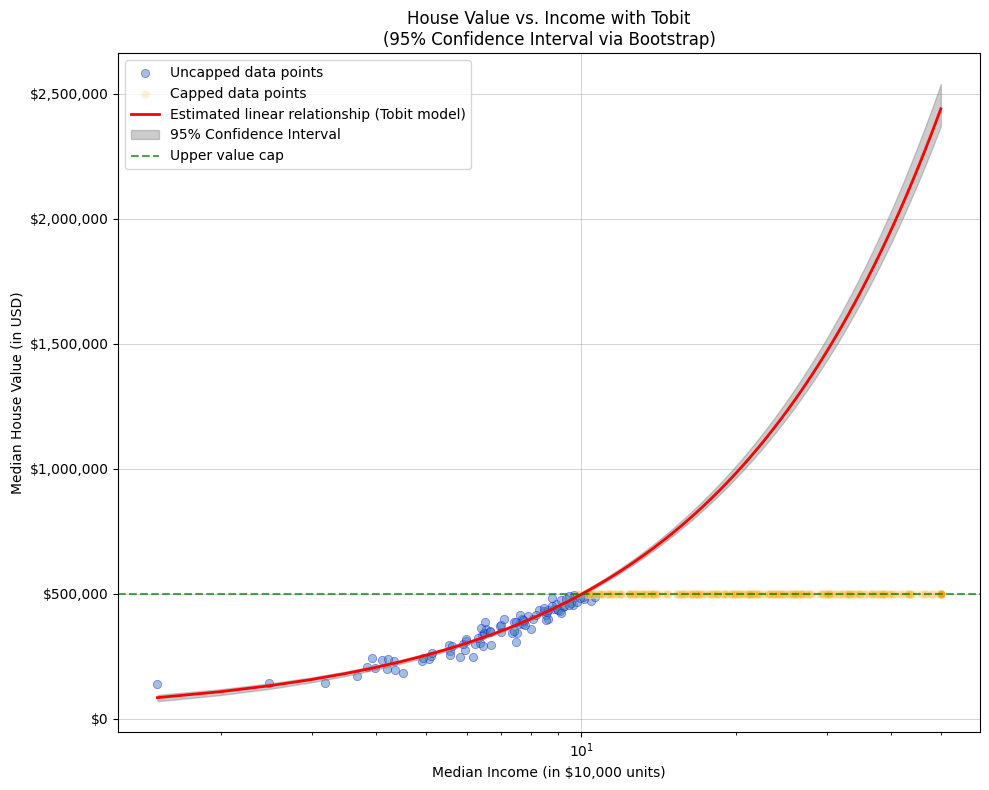

In [ ]:
# Create figure and axis objects
fig, ax = plt.subplots(figsize=(10, 8))

# Plot uncensored points using seaborn
sns.scatterplot(
	data=data_scenario_2[uncens],
	x="median_income_10k",
	y="median_house_value",
	alpha=0.5,
	color="steelblue",
	edgecolor="blue",
	label="Uncapped data points",
	ax=ax,
)

# Plot censored points using seaborn
sns.scatterplot(
	data=data_scenario_2[right_cens],
	x="median_income_10k",
	y="median_house_value",
	alpha=0.15,
	color="orange",
	label="Capped data points",
	ax=ax,
)

# Overlay the Tobit-estimated line
ax.plot(
	x_range,
	y_pred,
	color="red",
	linewidth=2,
	label="Estimated linear relationship (Tobit model)",
)

# Add confidence band
ax.fill_between(
	x_range,
	y_pred_lower,
	y_pred_upper,
	color="gray",
	alpha=0.4,
	label="95% Confidence Interval",
)

# Add cap line for context
ax.axhline(upper, color="green", linestyle="--", alpha=0.7, label="Upper value cap")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))

# Set scales and labels with units
ax.set_xscale("log")  # Spreads out the low-income blob
ax.set_xlabel("Median Income (in $10,000 units)")
ax.set_ylabel("Median House Value (in USD)")
ax.set_title(
	"House Value vs. Income with Tobit\n(95% Confidence Interval via Bootstrap)"
)
ax.grid(True, alpha=0.6, linewidth=0.4, color="grey")
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

#### Scenario 3: Comparing Many Distributions

  * **Goal:** A marketing team wants to compare the `total_bill` for customers across all seven days of the week, broken down by whether they were a smoker or non-smoker. They want to see the *entire distribution* for each of these 14 groups, not just the mean.

  * **Minimal Starter Dataset:** We can use a real dataset for this one.

In [ ]:
# Real Data
data_scenario_3 = sns.load_dataset("tips")

  * **The Task:** Design and implement a *single* chart that allows for a robust comparison of all 14 distributions (7 days x 2 smoker statuses). A simple bar chart is not allowed, as it only shows the mean.


### Part 2: The "Critique" Exercise (The Rogues' Gallery)

For each scenario below, I will describe a "bad" chart and provide the data that made it. Your task is to:

1.  **Diagnose:** Identify the primary flaw (e.g., "Truncated Y-axis," "3D distortion").
2.  **Explain:** In 1-2 sentences, explain *why* it is misleading, using the principles of graphical integrity (e.g., "It violates the principle of proportionality...").
3.  **Implement:** Write the code for the *honest* and *effective* chart that answers the original question.

#### Bad Chart 1: The "Exaggerated Difference"

  * **The Chart:** A manager presents a `barplot` to compare the "Customer Satisfaction Score" (CSAT) for two marketing campaigns. Campaign A has a 91.4% score, and Campaign B has a 92.1% score. The chart shows the bar for Campaign B as being almost *twice as tall* as the bar for Campaign A.
  * **The Data:**

In [ ]:
data_critique_1 = pd.DataFrame({
	"Campaign": ["Campaign A", "Campaign B"],
	"CSAT Score (%)": [91.4, 92.1],
})

  * **Your Task:** Diagnose the flaw, explain why it's a lie (use Tufte's "Lie Factor" concept), and create the *honest* chart.

#### Bad Chart 2: The "Perspective Lie"

  * **The Chart:** An intern creates a 3D Pie Chart to show the breakdown of sales by product category. The slices are: `Electronics` (40%), `Home Goods` (30%), `Clothing` (15%), and `Grocery` (15%). The chart is tilted, and the "Clothing" slice (15%) is in the foreground, making it look visually *larger* than the "Home Goods" slice (30%) in the background.
  * **The Data:**

In [ ]:
data_critique_2 = pd.DataFrame({
	"Category": ["Electronics", "Home Goods", "Clothing", "Grocery"],
	"Sales": [40, 30, 15, 15],
})

  * **Your Task:** Diagnose the flaw, explain why 3D pie charts are statistically unethical, and create a *better* chart (e.g., a bar chart or a clean 2D pie chart) that accurately represents the composition.

#### Bad Chart 3: The "Spurious Correlation"

  * **The Chart:** A blogger creates a line chart plotting two variables on *two different Y-axes*.
      * **Left Y-Axis (Blue Line):** "Global Average Temperature" (from 14.0 to 14.5 °C)
      * **Right Y-Axis (Red Line):** "Number of Software Developers" (from 15M to 25M)
      * The lines are scaled to perfectly overlap, making it look like the number of developers is *causing* global warming.
  * **The Data:**

In [ ]:
data_critique_3 = pd.DataFrame({
	"Year": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
	"Global_Temp_C": [
		14.01,
		14.05,
		14.10,
		14.12,
		14.18,
		14.25,
		14.31,
		14.35,
		14.40,
		14.45,
	],
	"Developers_M": [15.1, 15.5, 16.2, 17.0, 18.1, 19.0, 20.1, 21.5, 23.0, 24.5],
})

  * **Your Task:** Diagnose the flaw (it is called a "dual-axis" plot), explain why this is a classic statistical sin, and create an *honest* visualization (or two) to show the *real* relationship (or lack thereof). (Hint: What is the *correct* way to show a relationship between two numeric variables?).